In [6]:
!git clone https://github.com/mohamed-chtourou/detection-de-fraude.git

Cloning into 'detection-de-fraude'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 46 (delta 4), reused 43 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 865.71 KiB | 7.21 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [8]:
!pip install -r /kaggle/working/detection-de-fraude/requirements.txt -q

In [7]:
!python /kaggle/working/detection-de-fraude/step.py

Traceback (most recent call last):
  File "/kaggle/working/detection-de-fraude/pretraitement.py", line 10, in <module>
    train = pd.read_parquet("train_step2_preprocessed.parquet")
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 667, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 267, in read
    path_or_handle, handles, filesystem = _get_path_or_handle(
                                          ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 140, in _get_path_or_handle
    handles = get_handle(
              ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle, ioargs.mode)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'train_step2_

In [15]:
!python /kaggle/working/detection-de-fraude/step1_clean_and_preprocess.py

Traceback (most recent call last):
  File "/kaggle/working/detection-de-fraude/step1_clean_and_preprocess.py", line 5, in <module>
    train_trx = pd.read_csv("train_transaction.csv")
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1880, in _make_engine
    self.handles = get_handle(
                   ^

In [14]:
%cd /kaggle/working/detection-de-fraude
!git pull origin master

/kaggle/working/detection-de-fraude
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5 (delta 2), reused 5 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.97 KiB | 1.97 MiB/s, done.
From https://github.com/mohamed-chtourou/detection-de-fraude
 * branch            master     -> FETCH_HEAD
   4351186..9c694bb  master     -> origin/master
Updating 4351186..9c694bb
Fast-forward
 step1_clean_and_preprocess.py | 89 +++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 89 insertions(+)
 create mode 100644 step1_clean_and_preprocess.py


In [14]:
# ============================================
# CELL 3 : Configuration des chemins (CORRIGÉ)
# ============================================
import os
import sys

# ✅ Vos scripts sont à la racine du repo, pas dans src/
BASE_DIR = '/kaggle/working/detection-de-fraude'
sys.path.append(BASE_DIR)

# Chemins des données
KAGGLE_INPUT = "/kaggle/input/competitions/ieee-fraud-detection"
KAGGLE_OUTPUT = "/kaggle/working/detection-de-fraude"



print("✅ Environnement configuré")
print(f"📂 Scripts dans: {BASE_DIR}")
print(f"📂 Données: {KAGGLE_INPUT}")
print(f"📂 Output: {KAGGLE_OUTPUT}")

# Lister les scripts disponibles
print("\n📝 Scripts Python trouvés:")
import glob
scripts = glob.glob(f"{BASE_DIR}/*.py")
for script in sorted(scripts):
    print(f"   - {os.path.basename(script)}")

✅ Environnement configuré
📂 Scripts dans: /kaggle/working/detection-de-fraude
📂 Données: /kaggle/input/competitions/ieee-fraud-detection
📂 Output: /kaggle/working/detection-de-fraude

📝 Scripts Python trouvés:
   - features.py
   - model.py
   - pretraitement.py
   - step1_clean_and_preprocess.py


In [24]:
import re

def adapt_paths_for_kaggle(script_content: str) -> str:
    # 1) read_csv (fichiers simples)
    script_content = re.sub(
        r'pd\.read_csv\(\s*["\']train_transaction\.csv["\']\s*\)',
        f'pd.read_csv("{KAGGLE_INPUT}/train_transaction.csv")',
        script_content
    )
    script_content = re.sub(
        r'pd\.read_csv\(\s*["\']train_identity\.csv["\']\s*\)',
        f'pd.read_csv("{KAGGLE_INPUT}/train_identity.csv")',
        script_content
    )

    # 2) Parquet/CSV/etc : tout ce qui est relatif -> racine du repo
    script_content = re.sub(
        r'\.to_parquet\(\s*["\'](?!/)([^"\']+)["\']\s*\)',
        rf'.to_parquet("{KAGGLE_OUTPUT}/\1")',
        script_content
    )
    script_content = re.sub(
        r'pd\.read_parquet\(\s*["\'](?!/)([^"\']+)["\']\s*\)',
        rf'pd.read_parquet("{KAGGLE_OUTPUT}/\1")',
        script_content
    )
    script_content = re.sub(
        r'\.to_csv\(\s*["\'](?!/)([^"\']+)["\']\s*',
        rf'.to_csv("{KAGGLE_OUTPUT}/\1", ',
        script_content
    )
    script_content = re.sub(
        r'pd\.read_csv\(\s*["\'](?!/)([^"\']+\.csv)["\']\s*\)',
        rf'pd.read_csv("{KAGGLE_OUTPUT}/\1")',
        script_content
    )

    # 3) Modèle : si c'est juste un nom de fichier -> racine
    script_content = re.sub(
        r'["\']fraud_detection_models\.pkl["\']',
        f'"{KAGGLE_OUTPUT}/fraud_detection_models.pkl"',
        script_content
    )

    # 4) Figures : toute savefig relative -> racine
    script_content = re.sub(
        r'plt\.savefig\(\s*["\'](?!/)([^"\']+)["\']\s*\)',
        rf'plt.savefig("{KAGGLE_OUTPUT}/\1")',
        script_content
    )

    return script_content


In [34]:
# ============================================
# CELL 5 : Exécuter step1_clean_and_preprocess.py
# ============================================
print("="*70)
print("🔧 ÉTAPE 1 : PREPROCESSING (step1_clean_and_preprocess.py)")
print("="*70)
os.chdir("/kaggle/working/detection-de-fraude")
# ✅ Chemin corrigé - fichier à la racine
script_path = '/kaggle/working/detection-de-fraude/step1_clean_and_preprocess.py'

# Lire le script
with open(script_path, 'r') as f:
    script_content = f.read()

# Adapter les chemins
script_content = adapt_paths_for_kaggle(script_content)

# Exécuter
exec(script_content)

print("\n✅ Step 1 terminé!")

🔧 ÉTAPE 1 : PREPROCESSING (step1_clean_and_preprocess.py)
(590540, 394)
(144233, 41)
Shape après fusion : (590540, 434)
Nb colonnes à supprimer (>90% NaN): 12
Shape après suppression colonnes >90% NaN : (590540, 422)
NaN restants : 0

🔄 Encodage catégoriel...
  ✓ Frequency encoding : 12 colonnes
  ✓ Label encoding : 10 colonnes
✅ Encodage terminé.
✅ Sauvegardé : train_step2_preprocessed.parquet

✅ Step 1 terminé!



🔧 ÉTAPE 2 : PREPROCESSING AVANCÉ
✅ Chargé : (590540, 449)

⏰ Feature temporelle : fraude par heure...


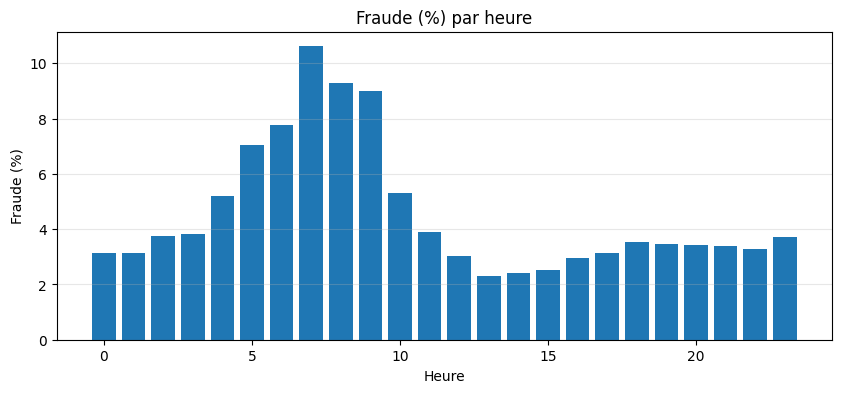

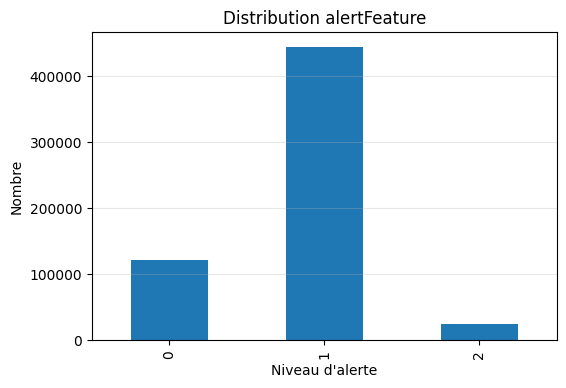


👤 Création UID + stats TransactionAmt...


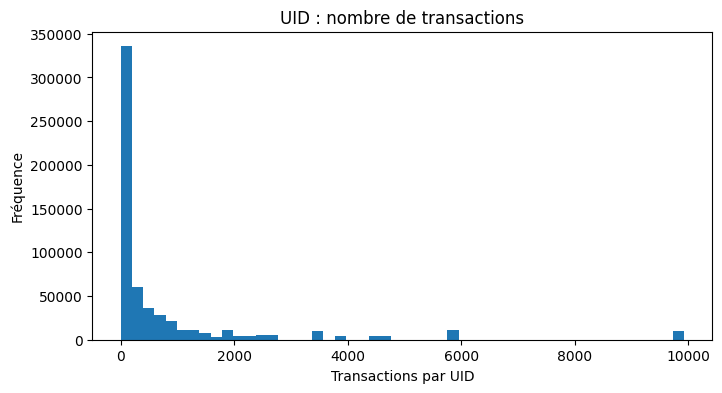


⏱️ Temps depuis dernière transaction...


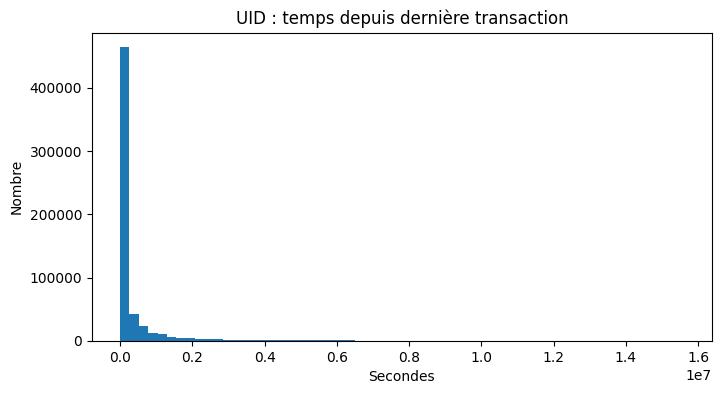


📱 Identification des appareils...


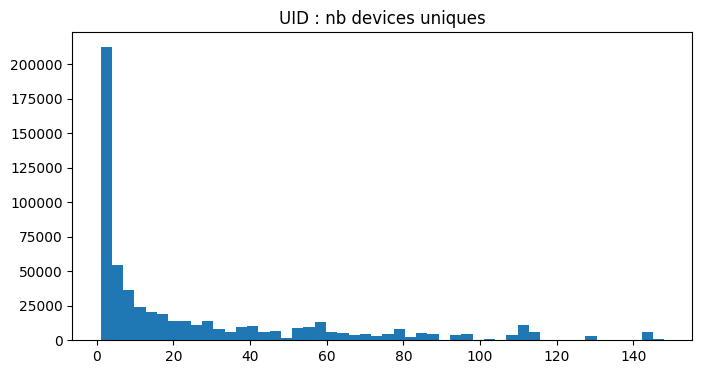

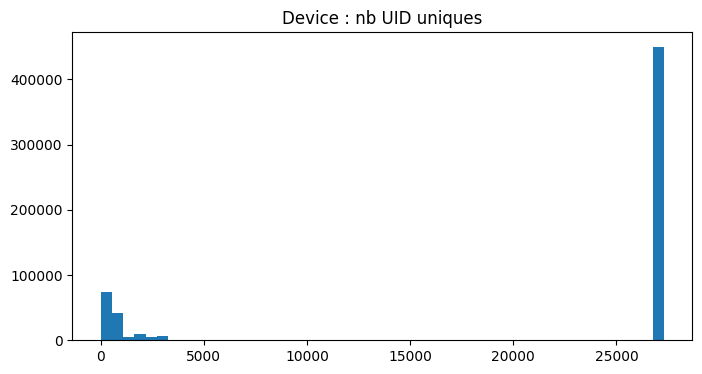


🧠 Features comportementales...


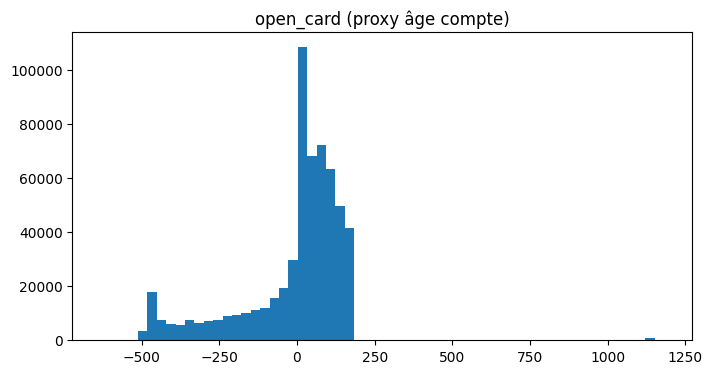

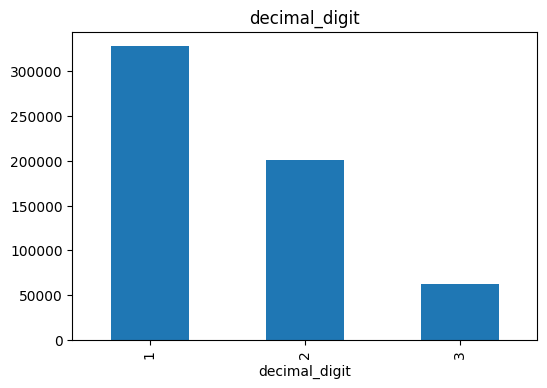

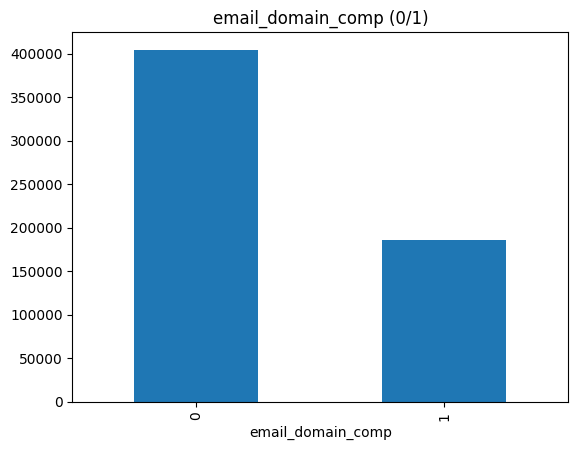


🔗 Feature Cross...


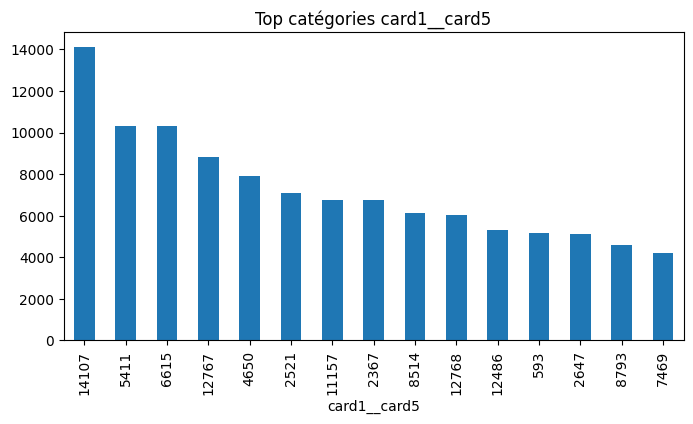

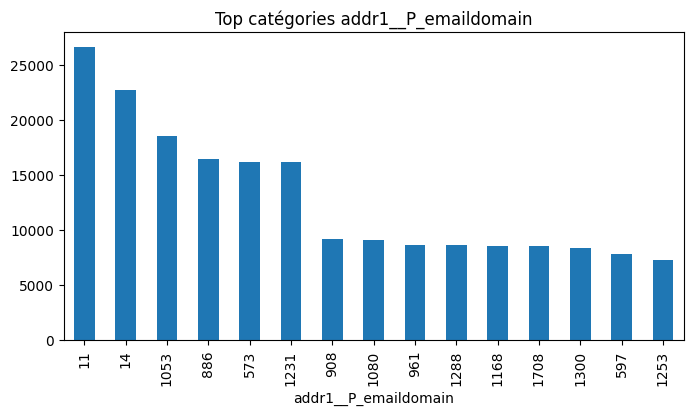


📊 CountEncoding...


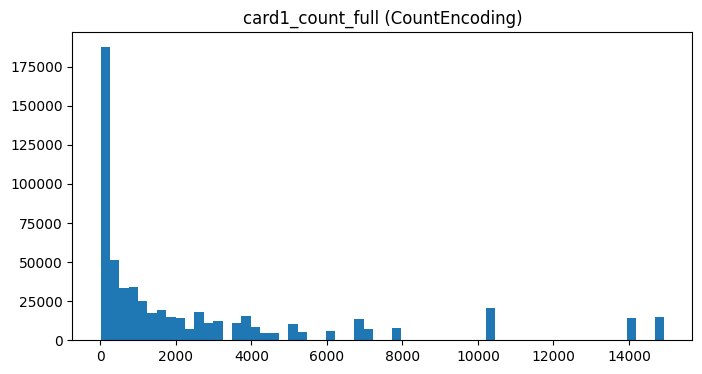

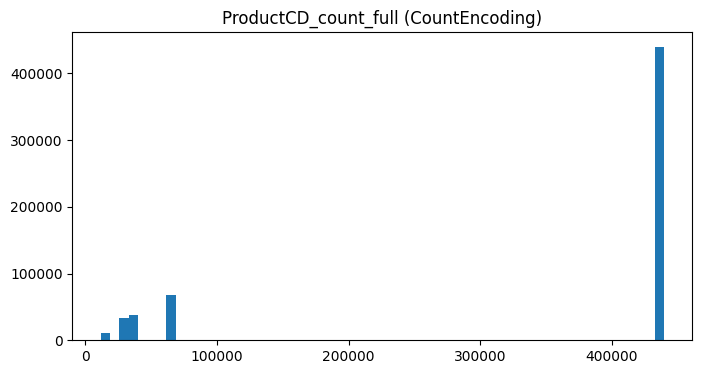


📌 Agrégation groupée par card1...


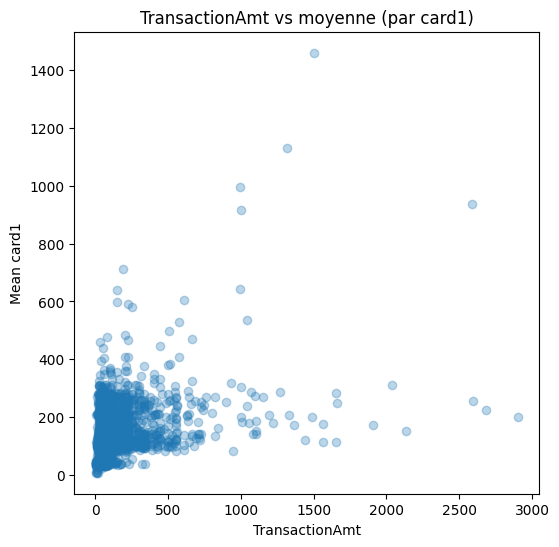


💾 Sauvegarde finale...
✅ Dataset final prêt pour le modèle !
Shape : (590540, 464)

✅ Preprocessing step 2 terminé!


In [35]:
# ============================================
# CELL 6 : Exécuter preprocessing_step2.py
# ============================================
print("\n" + "="*70)
print("🔧 ÉTAPE 2 : PREPROCESSING AVANCÉ")
print("="*70)
os.chdir("/kaggle/working/detection-de-fraude")
with open('/kaggle/working/detection-de-fraude/pretraitement.py', 'r') as f:
    script_content = f.read()

script_content = adapt_paths_for_kaggle(script_content)
exec(script_content)

print("\n✅ Preprocessing step 2 terminé!")

In [36]:
# ============================================
# CELL 7 : Exécuter features.py
# ============================================
print("\n" + "="*70)
print("🎨 ÉTAPE 3 : FEATURE ENGINEERING (features.py)")
print("="*70)
os.chdir("/kaggle/working/detection-de-fraude")
script_path = '/kaggle/working/detection-de-fraude/features.py'

with open(script_path, 'r') as f:
    script_content = f.read()

script_content = adapt_paths_for_kaggle(script_content)
exec(script_content)

print("\n✅ Feature engineering terminé!")


🎨 ÉTAPE 3 : FEATURE ENGINEERING (features.py)
✅ Chargé : (590540, 449)
✅ Step hour + alertFeature OK
✅ Step UID aggs OK
✅ Step temporel UID OK
✅ Step anomalies UID OK
✅ Step outliers OK
✅ Step device OK
✅ Step behaviour OK
✅ Step email OK
✅ Step feature cross OK: ['card1__card5', 'addr1__P_emaildomain']
✅ Step count encoding OK
✅ Step grouped aggs OK
✅ Sauvegardé : train_step3_features_light_plus.parquet
Shape: (590540, 490)
✅ Figures sauvegardées dans ./figures/

✅ Feature engineering terminé!


In [37]:
import gc, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import xgboost as xgb
from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# =====================================================
# CONFIG (8GB SAFE + GPU)
# =====================================================
TARGET = "isFraud"
RANDOM_STATE = 42
N_SPLITS = 4
EARLY_STOPPING = 150
PARQUET_PATH = "train_step3_features_light_plus.parquet"  # adapte si besoin

print("🚀 IEEE-CIS Fraud – Final GPU Pipeline (8GB Safe) [XGBoost 3.1+]")
start_time = time.time()

# =====================================================
# 1) LOAD
# =====================================================
print("\n1) Loading parquet...")
t0 = time.time()
df = pd.read_parquet(PARQUET_PATH)
print(f"✓ Loaded: {df.shape} in {time.time()-t0:.1f}s")

y = df[TARGET].astype(np.int8)
X = df.drop([TARGET, "TransactionID", "TransactionDT"], axis=1, errors="ignore")
print("Fraud rate:", float(y.mean()) * 100, "%")

# =====================================================
# 2) ENCODE categoricals + downcast (IMPORTANT for 8GB)
# =====================================================
print("\n2) Encoding categoricals + downcast...")
t0 = time.time()

obj_cols = X.select_dtypes(include=["object"]).columns
for col in obj_cols:
    X[col] = (
        X[col].astype("category")
              .cat.add_categories(["missing"])
              .fillna("missing")
              .cat.codes
              .astype(np.int32)
    )

for col in X.columns:
    if pd.api.types.is_float_dtype(X[col]):
        X[col] = pd.to_numeric(X[col], downcast="float")  # float32
    elif pd.api.types.is_integer_dtype(X[col]):
        X[col] = pd.to_numeric(X[col], downcast="integer")

print(f"✓ Done in {time.time()-t0:.1f}s | object cols: {len(obj_cols)}")

# Convert to numpy float32
X_np = X.to_numpy(dtype=np.float32, copy=True)
y_np = y.to_numpy(copy=True)

del X, y, df
gc.collect()

# =====================================================
# 3) HOLDOUT SPLIT
# =====================================================
print("\n3) Train/Test split...")
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_np, y_np, test_size=0.20, stratify=y_np, random_state=RANDOM_STATE
)
del X_np, y_np
gc.collect()

print("Trainval:", X_trainval.shape, "| Test:", X_test.shape)

# =====================================================
# 4) OOF (XGBoost GPU + CatBoost GPU)
# =====================================================
print("\n4) OOF training (GPU base models)...")
t0 = time.time()

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_xgb = np.zeros(X_trainval.shape[0], dtype=np.float32)
oof_cat = np.zeros(X_trainval.shape[0], dtype=np.float32)

xgb_best_iters = []
cat_best_iters = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f"\nFold {fold}/{N_SPLITS}")

    X_tr, X_va = X_trainval[tr_idx], X_trainval[va_idx]
    y_tr, y_va = y_trainval[tr_idx], y_trainval[va_idx]

    pos = int((y_tr == 1).sum())
    neg = int((y_tr == 0).sum())
    scale_pos_weight = float(neg) / float(max(pos, 1))

    # -----------------------------
    # XGBOOST (API native) GPU – XGBoost 3.1+
    # -----------------------------
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dvalid = xgb.DMatrix(X_va, label=y_va)

    xgb_params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",

        # ✅ XGBoost 3.x GPU setup:
        "tree_method": "hist",
        "device": "cuda",

        "max_depth": 7,
        "eta": 0.03,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "min_child_weight": 1.0,
        "lambda": 2.0,
        "alpha": 0.0,
        "scale_pos_weight": scale_pos_weight,
        "seed": RANDOM_STATE,
    }

    booster = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=4000,
        evals=[(dtrain, "train"), (dvalid, "valid")],
        early_stopping_rounds=EARLY_STOPPING,
        verbose_eval=False
    )

    best_xgb_iter = int(booster.best_iteration + 1)
    xgb_best_iters.append(best_xgb_iter)

    oof_xgb[va_idx] = booster.predict(
        dvalid, iteration_range=(0, best_xgb_iter)
    ).astype(np.float32)

    print(f"XGB best_iter={best_xgb_iter} | fold AUC={roc_auc_score(y_va, oof_xgb[va_idx]):.5f}")

    del dtrain, dvalid, booster
    gc.collect()

    # -----------------------------
    # CATBOOST GPU
    # -----------------------------
    cat = CatBoostClassifier(
        iterations=6000,
        depth=8,
        learning_rate=0.03,
        l2_leaf_reg=5.0,
        random_strength=1.0,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        task_type="GPU",
        devices="0",
        verbose=False,
        random_seed=RANDOM_STATE,
        od_type="Iter",
        od_wait=EARLY_STOPPING
    )

    cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)

    best_cat_iter = int(cat.get_best_iteration() or cat.get_params().get("iterations", 1))
    cat_best_iters.append(best_cat_iter)

    oof_cat[va_idx] = cat.predict_proba(X_va)[:, 1].astype(np.float32)
    print(f"CAT best_iter={best_cat_iter} | fold AUC={roc_auc_score(y_va, oof_cat[va_idx]):.5f}")

    del cat, X_tr, X_va, y_tr, y_va
    gc.collect()

print("\nOOF AUC XGB:", roc_auc_score(y_trainval, oof_xgb))
print("OOF AUC CAT:", roc_auc_score(y_trainval, oof_cat))
print(f"✓ OOF done in {time.time()-t0:.1f}s")

# =====================================================
# 5) STACKER (LogReg) on OOF
# =====================================================
print("\n5) Training stacker (LogReg)...")
X_stack = np.column_stack([oof_xgb, oof_cat]).astype(np.float32)

scaler = StandardScaler()
X_stack_s = scaler.fit_transform(X_stack)

stacker = LogisticRegression(C=2.0, solver="lbfgs", max_iter=2000)
stacker.fit(X_stack_s, y_trainval)

val_stack = stacker.predict_proba(X_stack_s)[:, 1]
print("Stacker Trainval AUC (optimistic):", roc_auc_score(y_trainval, val_stack))

# =====================================================
# 6) THRESHOLD tuning on OOF (maximize F1)
# =====================================================
print("\n6) Threshold tuning (F1 on OOF)...")
thresholds = np.linspace(0.05, 0.6, 80)
best_t, best_f1 = 0.5, -1.0
for t in thresholds:
    pred = (val_stack >= t).astype(np.int8)
    f1 = f1_score(y_trainval, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

print(f"Best threshold: {best_t:.3f} | F1: {best_f1:.5f}")

# =====================================================
# 7) REFIT base models on FULL trainval (GPU)
# =====================================================
print("\n7) Refitting base models on full trainval (GPU)...")
t0 = time.time()

best_xgb_iter = int(np.median(xgb_best_iters))
best_cat_iter = int(np.median(cat_best_iters))

pos = int((y_trainval == 1).sum())
neg = int((y_trainval == 0).sum())
scale_pos_weight_full = float(neg) / float(max(pos, 1))

# XGB full
dtrain_full = xgb.DMatrix(X_trainval, label=y_trainval)
xgb_params_full = dict(xgb_params)
xgb_params_full["scale_pos_weight"] = scale_pos_weight_full

booster_final = xgb.train(
    params=xgb_params_full,
    dtrain=dtrain_full,
    num_boost_round=best_xgb_iter,
    evals=[(dtrain_full, "train")],
    verbose_eval=False
)

# CAT full
cat_final = CatBoostClassifier(
    iterations=best_cat_iter,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    random_strength=1.0,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    task_type="GPU",
    devices="0",
    verbose=False,
    random_seed=RANDOM_STATE,
)

cat_final.fit(X_trainval, y_trainval, verbose=False)

print(f"✓ Refit done in {time.time()-t0:.1f}s | best_xgb_iter={best_xgb_iter} | best_cat_iter={best_cat_iter}")

# =====================================================
# 8) FINAL TEST EVAL
# =====================================================
print("\n8) Final test evaluation...")

dtest = xgb.DMatrix(X_test)
xgb_test_proba = booster_final.predict(dtest).astype(np.float32)
cat_test_proba = cat_final.predict_proba(X_test)[:, 1].astype(np.float32)

test_stack = np.column_stack([xgb_test_proba, cat_test_proba]).astype(np.float32)
test_stack_s = scaler.transform(test_stack)

test_proba = stacker.predict_proba(test_stack_s)[:, 1]
test_pred = (test_proba >= best_t).astype(np.int8)

print("\n🏁 FINAL TEST RESULTS")
print("AUC :", roc_auc_score(y_test, test_proba))
print("F1  :", f1_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

print(f"\n⏱️ Total time: {time.time()-start_time:.1f}s ({(time.time()-start_time)/60:.1f}min)")


🚀 IEEE-CIS Fraud – Final GPU Pipeline (8GB Safe) [XGBoost 3.1+]

1) Loading parquet...
✓ Loaded: (590540, 490) in 2.7s
Fraud rate: 3.4990009144173126 %

2) Encoding categoricals + downcast...
✓ Done in 3.6s | object cols: 31

3) Train/Test split...
Trainval: (472432, 487) | Test: (118108, 487)

4) OOF training (GPU base models)...

Fold 1/4
XGB best_iter=4000 | fold AUC=0.97507


Default metric period is 5 because AUC is/are not implemented for GPU


CAT best_iter=5966 | fold AUC=0.97183

Fold 2/4
XGB best_iter=3163 | fold AUC=0.97169


Default metric period is 5 because AUC is/are not implemented for GPU


CAT best_iter=4758 | fold AUC=0.96827

Fold 3/4
XGB best_iter=3998 | fold AUC=0.97193


...

CAT best_iter=4215 | fold AUC=0.96593

Fold 4/4
XGB best_iter=3240 | fold AUC=0.96906


Default metric period is 5 because AUC is/are not implemented for GPU


CAT best_iter=5999 | fold AUC=0.96458

OOF AUC XGB: 0.9717731913882862
OOF AUC CAT: 0.9673257479983512
✓ OOF done in 1165.2s

5) Training stacker (LogReg)...
Stacker Trainval AUC (optimistic): 0.971713479417254

6) Threshold tuning (F1 on OOF)...
Best threshold: 0.475 | F1: 0.82005

7) Refitting base models on full trainval (GPU)...


Default metric period is 5 because AUC is/are not implemented for GPU


✓ Refit done in 344.3s | best_xgb_iter=3619 | best_cat_iter=5362

8) Final test evaluation...

🏁 FINAL TEST RESULTS
AUC : 0.9789592856983261
F1  : 0.8444614015006995
Precision: 0.8900804289544236
Recall   : 0.8032905879506412
Confusion Matrix:
 [[113565    410]
 [   813   3320]]

⏱️ Total time: 1527.6s (25.5min)
